In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import requests

In [4]:
def fetch_real_county_data(state_fips='37'):
    
    base_url = "https://api.census.gov/data"
    
    variables = [
        'NAME',
        'B08301_021E',    # WFH workers
        'B08301_001E',    # Total workers
        'B19013_001E',    # Median income
        'B28002_004E',    # Has broadband
        'B28002_001E',    # Total households
    ]
    vars_str = ','.join(variables)
    
    all_data = []
    
    # Fetch for each state
    states_to_fetch = [state_fips]
    
    for state in states_to_fetch:
        state_name = 'North Carolina'
        print(f"Fetching data for {state_name}...")
        
        # 2019 baseline
        url_2019 = f"{base_url}/2019/acs/acs5"
        params_2019 = {'get': vars_str, 'for': 'county:*', 'in': f'state:{state}'}
        resp_2019 = requests.get(url_2019, params=params_2019)
        
        # 2022 current (latest available)
        url_2022 = f"{base_url}/2022/acs/acs5"
        params_2022 = {'get': vars_str, 'for': 'county:*', 'in': f'state:{state}'}
        resp_2022 = requests.get(url_2022, params=params_2022)
        
        if resp_2019.status_code == 200 and resp_2022.status_code == 200:
            data_2019 = resp_2019.json()
            data_2022 = resp_2022.json()
            
            df_2019 = pd.DataFrame(data_2019[1:], columns=data_2019[0])
            df_2022 = pd.DataFrame(data_2022[1:], columns=data_2022[0])
            
            # Process
            df_2019['GEOID'] = df_2019['state'] + df_2019['county']
            df_2022['GEOID'] = df_2022['state'] + df_2022['county']
            
            df_2019 = df_2019.rename(columns={
                'B08301_021E': 'WFH_Workers_2019',
                'B08301_001E': 'Total_Workers_2019',
            })
            
            df_2022 = df_2022.rename(columns={
                'B08301_021E': 'WFH_Workers_2023',
                'B08301_001E': 'Total_Workers_2023',
                'B19013_001E': 'Median_Income',
                'B28002_004E': 'Broadband_HH',
                'B28002_001E': 'Total_HH',
            })
            
            # Merge
            df_merged = pd.merge(
                df_2019[['GEOID', 'WFH_Workers_2019', 'Total_Workers_2019']],
                df_2022[['GEOID', 'NAME', 'WFH_Workers_2023', 'Total_Workers_2023', 
                        'Median_Income', 'Broadband_HH', 'Total_HH']],
                on='GEOID'
            )
            
            all_data.append(df_merged)
        else:
            print(f"  ✗ Error fetching data for state {state}")
    
    if not all_data:
        print("ERROR: No data fetched!")
        return None
    
    # Combine all states
    df = pd.concat(all_data, ignore_index=True)
    
    # Convert to numeric
    numeric_cols = ['WFH_Workers_2019', 'Total_Workers_2019', 'WFH_Workers_2023', 
                   'Total_Workers_2023', 'Median_Income', 'Broadband_HH', 'Total_HH']
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # Calculate broadband
    df['Broadband_Pct'] = (df['Broadband_HH'] / df['Total_HH'] * 100).round(1)
    
    # Clean county names
    df['County'] = df['NAME'].str.replace(', North Carolina', '').str.replace(', South Carolina', ' (SC)').str.replace(' County', '')
    df['State'] = df['NAME'].apply(lambda x: 'NC' if 'North Carolina' in x else 'SC')
    
    # Hardcoded land areas for Charlotte metro counties (in sq miles)
    # Source: Census Bureau geographic data
    land_areas = {
        'Mecklenburg': 546,
        'Union': 640,
        'Cabarrus': 364,
        'Gaston': 364,
        'Iredell': 597
    }
    df['Land_Area_SqMi'] = df['County'].map(land_areas).fillna(500)  # Default 500 for others
    
    print(f"✓ Fetched {len(df)} counties")
    
    return df

In [5]:
def fetch_real_tract_data(state_fips='37', county_fips='119'):
    """
    Fetch census tract data for a specific county
    
    Args:
        state_fips: '37' = NC
        county_fips: '119' = Mecklenburg County (Charlotte)
    """
    
    base_url = "https://api.census.gov/data/2022/acs/acs5"
    
    variables = [
        'NAME',
        'B08301_021E',
        'B08301_001E',
        'B19013_001E',
        'B28002_004E',
        'B28002_001E',
    ]
    
    params = {
        'get': ','.join(variables),
        'for': 'tract:*',
        'in': f'state:{state_fips} county:{county_fips}'
    }
    
    print(f"Fetching tract data for county {county_fips}...")
    resp = requests.get(base_url, params=params)
    
    if resp.status_code != 200:
        print(f"Error: {resp.status_code}")
        return None
    
    data = resp.json()
    df = pd.DataFrame(data[1:], columns=data[0])
    
    df = df.rename(columns={
        'B08301_021E': 'WFH_Workers',
        'B08301_001E': 'Total_Workers',
        'B19013_001E': 'Median_Income',
        'B28002_004E': 'Broadband_HH',
        'B28002_001E': 'Total_HH',
    })
    
    numeric_cols = ['WFH_Workers', 'Total_Workers', 'Median_Income', 'Broadband_HH', 'Total_HH']
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    
    df['Broadband_Pct'] = (df['Broadband_HH'] / df['Total_HH'] * 100).round(1)
    df['Tract_Name'] = 'Tract ' + df['tract']
    df['GEOID'] = df['state'] + df['county'] + df['tract']
    
    # Filter unreliable data
    df = df[df['Total_Workers'] >= 100]
    
    print(f"✓ Fetched {len(df)} tracts")
    
    return df

In [6]:
def chart_1_wfh_growth(df_counties):
    """Bar chart: 2019 vs 2023 WFH rates by county"""
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    x = np.arange(len(df_counties))
    width = 0.35
    
    ax.bar(x - width/2, df_counties['WFH_Rate_2019'], width, label='2019', alpha=0.8, color='steelblue')
    ax.bar(x + width/2, df_counties['WFH_Rate_2023'], width, label='2023', alpha=0.8, color='coral')
    
    ax.set_xlabel('County', fontsize=12, fontweight='bold')
    ax.set_ylabel('WFH Rate (%)', fontsize=12, fontweight='bold')
    ax.set_title('WFH Growth: Charlotte Metro (2019 vs 2022)', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(df_counties['County'], rotation=45, ha='right')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    
    for i, (idx, row) in enumerate(df_counties.iterrows()):
        ax.text(i, row['WFH_Rate_2023'] + 0.5, f"+{row['WFH_Growth_Pct']:.0f}%", 
               ha='center', va='bottom', fontsize=9, fontweight='bold', color='darkred')
    
    plt.tight_layout()
    return fig


In [10]:
def calculate_metrics(df_counties, df_tracts=None):
    """Add derived columns"""
    
    # County metrics
    df_counties['WFH_Rate_2019'] = (df_counties['WFH_Workers_2019'] / df_counties['Total_Workers_2019'] * 100).round(1)
    df_counties['WFH_Rate_2023'] = (df_counties['WFH_Workers_2023'] / df_counties['Total_Workers_2023'] * 100).round(1)
    df_counties['WFH_Growth_Pct'] = ((df_counties['WFH_Rate_2023'] - df_counties['WFH_Rate_2019']) / df_counties['WFH_Rate_2019'] * 100).round(1)
    df_counties['WFH_Absolute_Growth'] = df_counties['WFH_Workers_2023'] - df_counties['WFH_Workers_2019']
    df_counties['Broadband_Gap'] = 100 - df_counties['Broadband_Pct']
    df_counties['WFH_Density'] = (df_counties['WFH_Workers_2023'] / df_counties['Land_Area_SqMi']).round(1)
    df_counties['Market_Value_Score'] = (df_counties['WFH_Workers_2023'] * df_counties['Median_Income'] * df_counties['Broadband_Gap'] / 1e9).round(2)
    
    if df_tracts is not None:
        # Tract metrics
        df_tracts['WFH_Rate'] = (df_tracts['WFH_Workers'] / df_tracts['Total_Workers'] * 100).round(1)
        df_tracts['Broadband_Gap'] = 100 - df_tracts['Broadband_Pct']
        df_tracts['Market_Value'] = (df_tracts['WFH_Workers'] * df_tracts['Median_Income'] * df_tracts['Broadband_Gap'] / 1e6).round(2)
        return df_counties, df_tracts
    
    return df_counties

Fetching data for North Carolina...
✓ Fetched 100 counties
Fetching tract data for county 119...
✓ Fetched 302 tracts
✓ Chart 1 saved


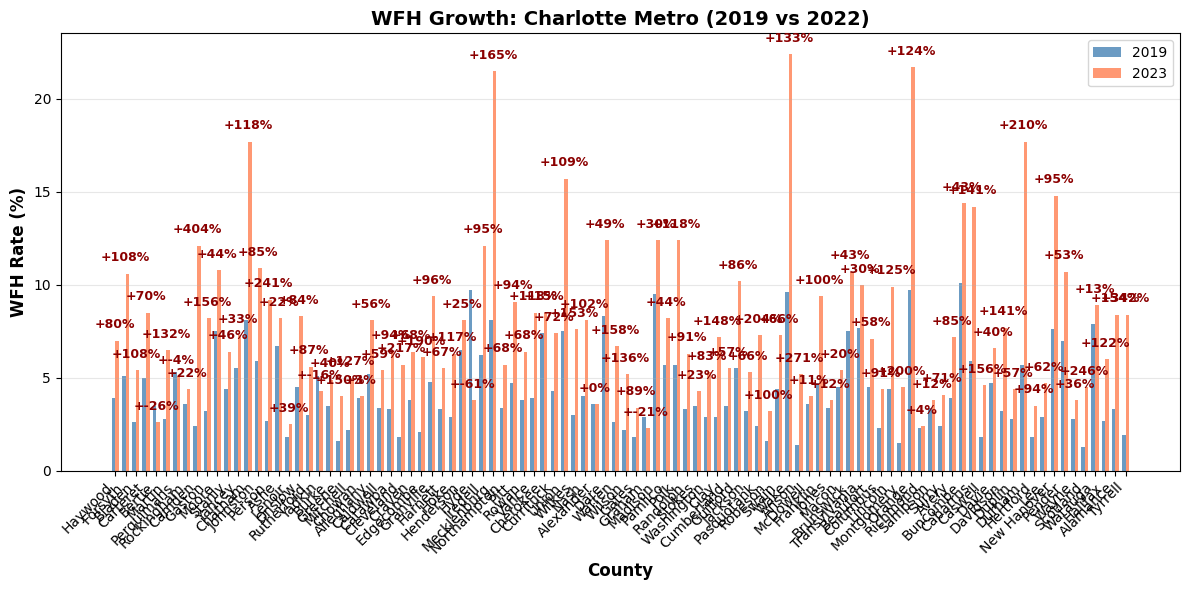

In [11]:
df_counties = fetch_real_county_data(state_fips='37')
charlotte_metro = ['Mecklenburg', 'Union', 'Cabarrus', 'Gaston', 'Iredell']

# Fetch tract data for Mecklenburg County
df_tracts = fetch_real_tract_data(state_fips='37', county_fips='119')

df_counties, df_tracts = calculate_metrics(df_counties, df_tracts)

fig1 = chart_1_wfh_growth(df_counties)
plt.savefig('chart1_wfh_growth_REAL.png', dpi=150, bbox_inches='tight')
print("✓ Chart 1 saved")